# GUV scale-up model: example run

This notebook walks through a full example of the germicidal UV (GUV) scale-up model:

1. **Imports** – Load the model and plotting code from the `src` package.
2. **Parameter sampling** – Draw Monte Carlo samples for market sizes, costs, and CADR per unit.
3. **Baseline supply** – Compute current UV and repurposed fluorescent lamp supply (baseline CADR).
4. **CADR requirement** – Estimate total clean-air delivery rate needed for vital workers.
5. **Growth models** – Run the scale-up model for UV and for repurposed fluorescent lamps.
6. **Plot** – Compare supply ramp-up vs requirement over time (with optional confidence interval).

In [ ]:
# Add repo root so we can import from src (run this cell first)
import sys
from pathlib import Path

here = Path().resolve()
root = here.parent if here.name == "scripts" else here
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
from src.mc_distributions import sample_normal, sample_lognormal
from src.scale_up_model import growth_model, calculate_stats
from src.plotter import plot_uv_fluoro_ramp

## 1. Parameter sampling

Draw Monte Carlo samples for market sizes, usable fractions, costs, and CADR per unit. We use 1000 simulations per run; you can change `n_sims` to trade off speed vs smoothness of the bands.

In [ ]:
n_sims = 1000

#TODO: add far-uvc and split out ur-uv
# UV lamp market and supply chain
global_uv_market = sample_normal(6.3e8, 5.0e9, n_sims)
percent_usable_uv = sample_normal(0.60, 0.90, n_sims)
percent_of_annual_uv = sample_normal(0.5 / 12, 1 / 12, n_sims)
cost_per_unit_uv = sample_lognormal(100, 700, n_sims)
cadr_per_unit = sample_lognormal(100, 500, n_sims)  # same for UV and fluoro lamps

# Repurposed fluorescent lamp market (no current annual production → baseline 0)
global_fluoro_market = sample_normal(2.8e9, 7.9e9, n_sims)
percent_usable_fluoro = sample_normal(0.60, 0.90, n_sims)
cost_per_unit_fluoro = sample_lognormal(1, 3, n_sims)

# CADR requirement 
quanta_relative_to_covid = 5 # how much more infectious than covid
ashrae_req = sample_normal(35 * quanta_relative_to_covid, 45 * quanta_relative_to_covid, n_sims)
vital_workers = sample_normal(0.5e9, 1e9, n_sims)

## 2. Baseline supply

Compute current (month 0) global CADR from UV lamps and from repurposed fluorescent lamps. UV has existing production; fluoro is set to zero here (ramp-up is from repurposing only).

In [ ]:
global_uv_market_usable = global_uv_market * percent_usable_uv

# calculate baseline cadr from existing stock in factories and retailers
annual_uv_market_usable = global_uv_market_usable * percent_of_annual_uv
uv_lamps = annual_uv_market_usable / cost_per_unit_uv
uv_baseline_cadr = uv_lamps * cadr_per_unit

# No current annual repurposed fluoro production → baseline 0
fluoro_baseline_cadr = np.zeros(n_sims)
global_fluoro_market_usable = global_fluoro_market * percent_usable_fluoro

## 3. CADR requirement

Estimate total CADR needed for vital workers (e.g. healthcare, food supply) using ASHRAE-style ventilation and a range for the number of vital workers.

In [ ]:
total_cadr_req = ashrae_req * vital_workers

## 4. Growth models

Run the scale-up model for UV lamps (ramp from current production) and for repurposed fluorescent lamps (ramp from zero). Tweak `months` and the utilization/repurposing parameters to match your scenario.

In [5]:
months = 6

uv_monthly_cadr = growth_model(
    baseline_cadr=uv_baseline_cadr,
    global_market_usable=global_uv_market_usable,
    cost_per_unit=cost_per_unit_uv,
    cadr_per_unit=cadr_per_unit,
    months=months,
    utilization_start=1.0,
    utilization_end=1.0,
    utilization_ramp_months=3,
    additional_annual_production=1 / 12,
    repurposed_ramp_months=1,
    repurposed_annual_production=3 / 12,
)

fluoro_monthly_cadr = growth_model(
    baseline_cadr=fluoro_baseline_cadr,
    global_market_usable=global_fluoro_market_usable,
    cost_per_unit=cost_per_unit_fluoro,
    cadr_per_unit=cadr_per_unit,
    months=months,
    utilization_start=0.0,
    utilization_end=0.7,
    utilization_ramp_months=3,
    additional_annual_production=1 / 12,
    repurposed_ramp_months=0,
    repurposed_annual_production=0,
)

## 5. Plot

Compare UV supply, repurposed fluorescent supply, and CADR requirement over time. Use `confidence_interval` (e.g. 90 or 50) to control the shaded bands; use `save_path` to write a figure to disk.

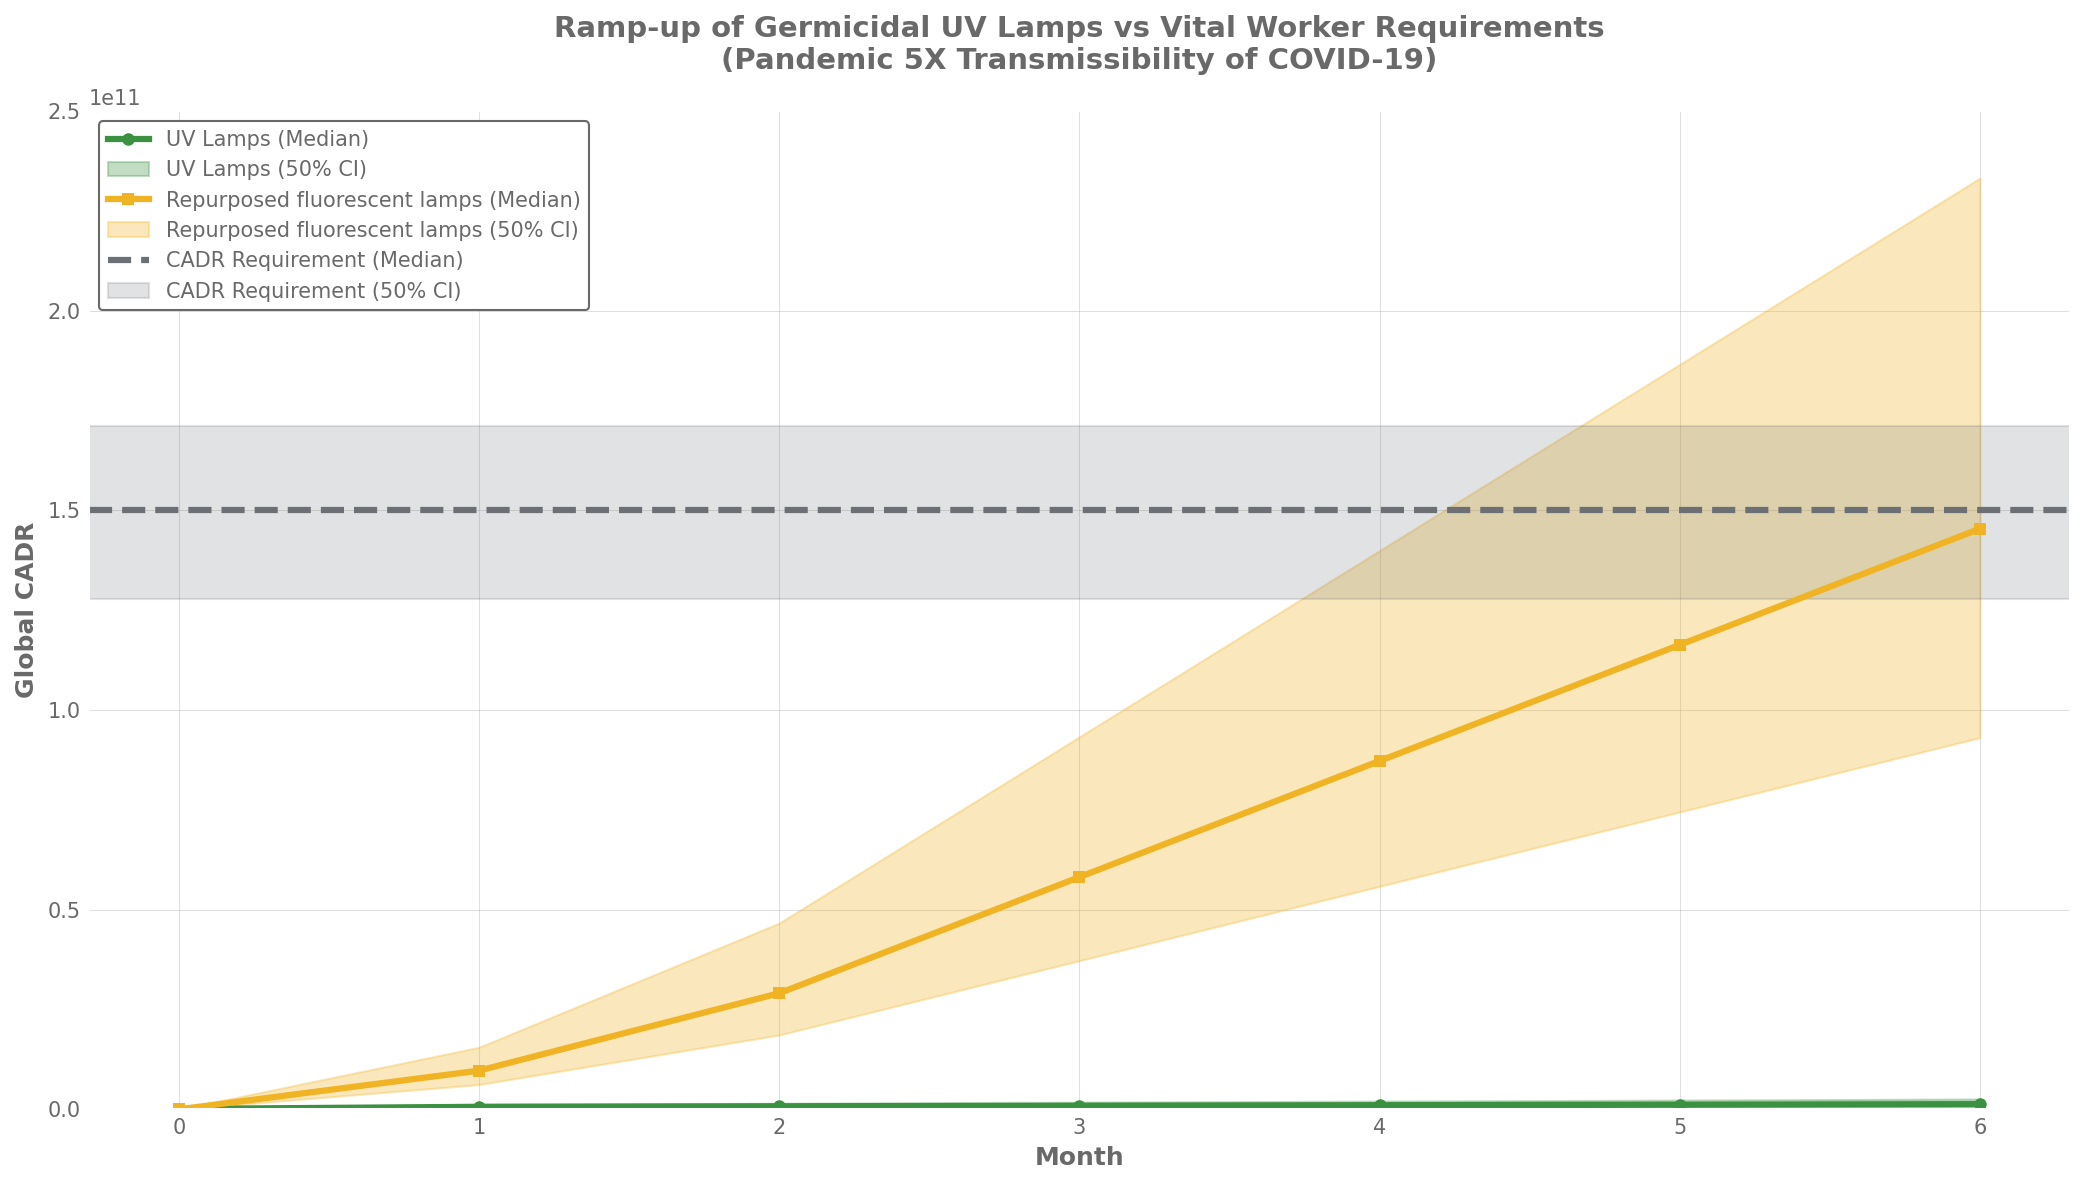

(<Figure size 2100x1200 with 1 Axes>,
 <Axes: title={'center': 'Ramp-up of Germicidal UV Lamps vs Vital Worker Requirements\n(Pandemic 5X Transmissibility of COVID-19)'}, xlabel='Month', ylabel='Global CADR'>)

In [8]:
plot_uv_fluoro_ramp(
    uv_monthly_cadr,
    fluoro_monthly_cadr,
    total_cadr_req,
    confidence_interval=90,
    save_path=None,  # e.g. "results/ramp.png"
    show=True,
)